<a href="https://colab.research.google.com/github/muhammadzohaib09001-dotcom/FACIAL_EMOTION_RECOGNATION_USING_CNN_TRANSFER_LEARNING/blob/main/FacialEmotionRecognition_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# PAM2002 Data Science Project
##Facial Emotion Recognition Using CNN and Transfer Learning
##Student: Muhammad Zohaib Khan
##Module: 7PAM2002 Data Science Project
##Semester: A 2025/2026

---

## Research Questions
1. How do different data preprocessing and augmentation methods affect the performance of facial emotion recognition models?
2. How do different CNN architectures compare in extracting facial features for emotion recognition?
3. How does the performance of CNN-based models compare with that of Transfer models for facial emotion recognition from images?
4. How do CNN and Transfer models differ in classification performance and error patterns when evaluated using standard metrics?

# Importing Libraries



In [1]:
import os
import random
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models

from sklearn.metrics import classification_report, confusion_matrix
from sklearn.utils.class_weight import compute_class_weight

In [2]:
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("TensorFlow version:", tf.__version__)
print("GPU available:", tf.config.list_physical_devices('GPU'))

TensorFlow version: 2.20.0
GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


# Dataset Loading

In [3]:
dataset_path = "/content/drive/MyDrive/emotion-recognition-dataset/Dataset/dataset/"

print("Dataset path exists:", os.path.exists(dataset_path))
print("Folders/classes:", os.listdir(dataset_path))

Dataset path exists: True
Folders/classes: ['Sad', 'Neutral', 'Surprise', 'Happy', 'Angry', 'Ahegao']


Setting Image and Batch Side

In [4]:
IMG_SIZE = (64, 64)
BATCH_SIZE = 32

Loading the dataset using Keras:

In [5]:
train_ds = tf.keras.utils.image_dataset_from_directory(
    dataset_path,
    validation_split=0.30,
    subset="training",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="int"
)

temp_ds = tf.keras.utils.image_dataset_from_directory(
    dataset_path,
    validation_split=0.30,
    subset="validation",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="int"
)

Found 15454 files belonging to 6 classes.
Using 10818 files for training.
Found 15454 files belonging to 6 classes.
Using 4636 files for validation.


Now spliting the temporary 30% into validation and test sets.

In [6]:
val_batches = tf.data.experimental.cardinality(temp_ds)
test_ds = temp_ds.take(val_batches // 2)
val_ds = temp_ds.skip(val_batches // 2)

class_names = train_ds.class_names
num_classes = len(class_names)

print("Class names:", class_names)
print("Number of classes:", num_classes)

Class names: ['Ahegao', 'Angry', 'Happy', 'Neutral', 'Sad', 'Surprise']
Number of classes: 6


# Exploratory Data Analysis

**Display Sample Images**

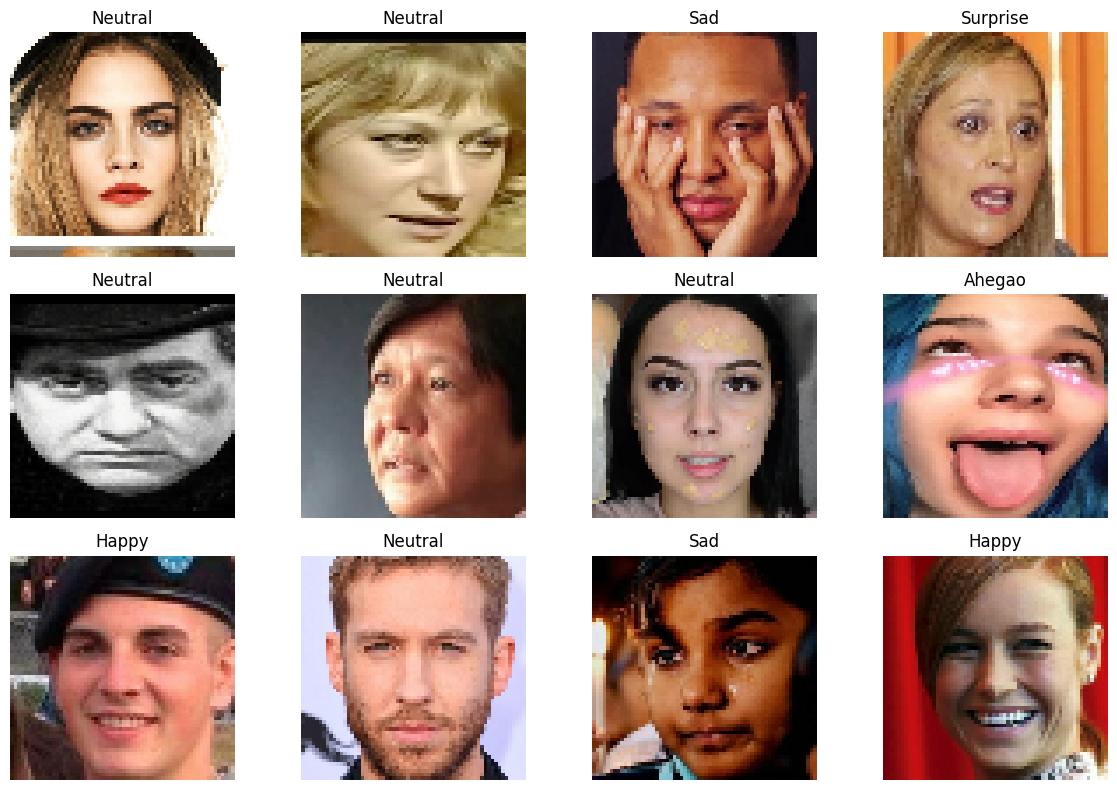

In [7]:
plt.figure(figsize=(12, 8))

for images, labels in train_ds.take(1):
    for i in range(min(12, len(images))):
        plt.subplot(3, 4, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(class_names[labels[i]])
        plt.axis("off")

plt.tight_layout()
plt.show()

**Class Distribution**

In [8]:
class_counts = {}

for class_name in class_names:
    class_dir = os.path.join(dataset_path, class_name)
    class_counts[class_name] = len([
        file for file in os.listdir(class_dir)
        if file.lower().endswith((".jpg", ".jpeg", ".png", ".bmp", ".webp"))
    ])

print("Class distribution:")
for class_name, count in class_counts.items():
    print(f"{class_name}: {count}")

Class distribution:
Ahegao: 1206
Angry: 1313
Happy: 3740
Neutral: 4027
Sad: 3934
Surprise: 1234


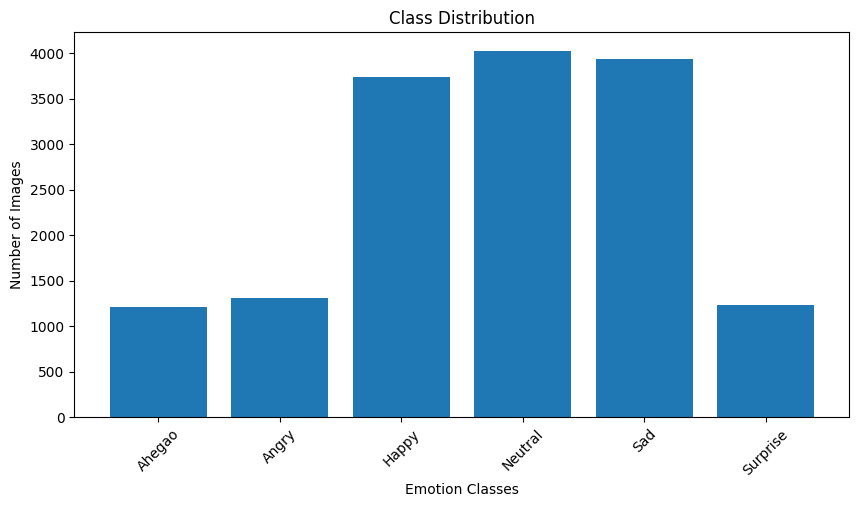

In [9]:
plt.figure(figsize=(10, 5))
plt.bar(class_counts.keys(), class_counts.values())
plt.xlabel("Emotion Classes")
plt.ylabel("Number of Images")
plt.title("Class Distribution")
plt.xticks(rotation=45)
plt.show()

# Data Preprocessing & Class Imbalance Handling

Images loaded by image_dataset_from_directory are originally in the range 0 to 255. We will normalize them to 0 to 1 inside the model using a Rescaling layer.
 For imbalance handling, we will calculate class weights.

In [10]:
all_labels = []

for class_index, class_name in enumerate(class_names):
    class_dir = os.path.join(dataset_path, class_name)

    image_files = [
        file for file in os.listdir(class_dir)
        if file.lower().endswith((".jpg", ".jpeg", ".png", ".bmp", ".webp"))
    ]

    all_labels.extend([class_index] * len(image_files))

all_labels = np.array(all_labels)

class_weights_values = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(all_labels),
    y=all_labels
)

class_weights = {
    i: class_weights_values[i]
    for i in range(len(class_weights_values))
}

print("Class weights:")
print(class_weights)

Class weights:
{0: np.float64(2.1357103372028745), 1: np.float64(1.9616653973089617), 2: np.float64(0.6886809269162211), 3: np.float64(0.6395993709130039), 4: np.float64(0.6547195390611761), 5: np.float64(2.0872501350621286)}


These weights will be passed to model.fit() later:

In [11]:
class_weight=class_weights

# Data Augmentation & DataLoaders

In [12]:
data_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
    layers.RandomTranslation(0.1, 0.1)
], name="data_augmentation")

**Improve Loading Performance**

In [13]:
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)
test_ds = test_ds.cache().prefetch(buffer_size=AUTOTUNE)

# Defining Simple Custom CNN Model

In [14]:
model = keras.Sequential([
    layers.Input(shape=(64, 64, 3)),

    layers.Rescaling(1./255),

    data_augmentation,

    layers.Conv2D(16, (3, 3), activation="relu", padding="same"),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(32, (3, 3), activation="relu", padding="same"),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(64, (3, 3), activation="relu", padding="same"),
    layers.MaxPooling2D((2, 2)),

    layers.Flatten(),

    layers.Dense(128, activation="relu"),
    layers.Dropout(0.5),

    layers.Dense(num_classes, activation="softmax")
])

**Model Summery**

In [15]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)           │ (None, 64, 64, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augmentation (Sequential)  │ (None, 64, 64, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 64, 64, 16)     │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 32, 32, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       524,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 548,774 (2.09 MB)

 Trainable params: 548,774 (2.09 MB)

 Non-trainable params: 0 (0.00 B)

**Compile the Model**

In [16]:
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

# Train the Simple CNN Model

In [17]:
EPOCHS = 35

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    class_weight=class_weights
)

Epoch 1/35
339/339 ━━━━━━━━━━━━━━━━━━━━ 25s 23ms/step - accuracy: 0.2281 - loss: 1.7115 - val_accuracy: 0.2809 - val_loss: 1.6381
Epoch 2/35
339/339 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.3064 - loss: 1.5622 - val_accuracy: 0.2899 - val_loss: 1.6248
Epoch 3/35
339/339 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.3260 - loss: 1.5039 - val_accuracy: 0.3396 - val_loss: 1.5142
Epoch 4/35
339/339 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.3475 - loss: 1.4579 - val_accuracy: 0.3563 - val_loss: 1.5197
Epoch 5/35
339/339 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.3586 - loss: 1.4101 - val_accuracy: 0.3846 - val_loss: 1.3887
Epoch 6/35
339/339 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.3623 - loss: 1.3876 - val_accuracy: 0.4202 - val_loss: 1.4018
Epoch 7/35
339/339 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.3817 - loss: 1.3546 - val_accuracy: 0.4262 - val_loss: 1.3633
Epoch 8/35
339/339 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.3944 - loss: 1.3250 - val_accuracy: 

**Plot Training and Validation Results**

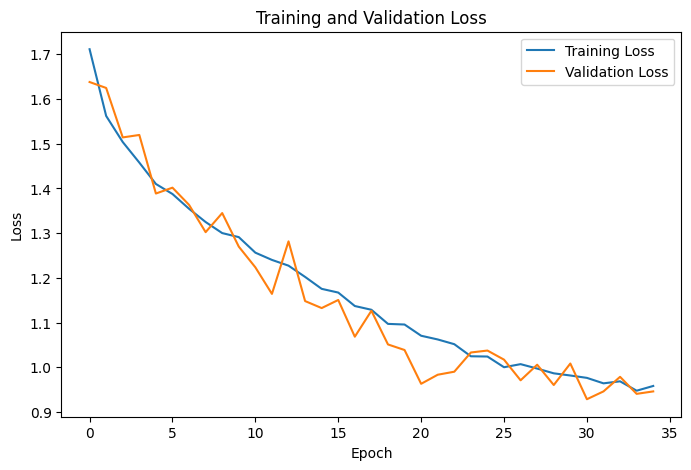

In [18]:
plt.figure(figsize=(8, 5))
plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")
plt.legend()
plt.show()

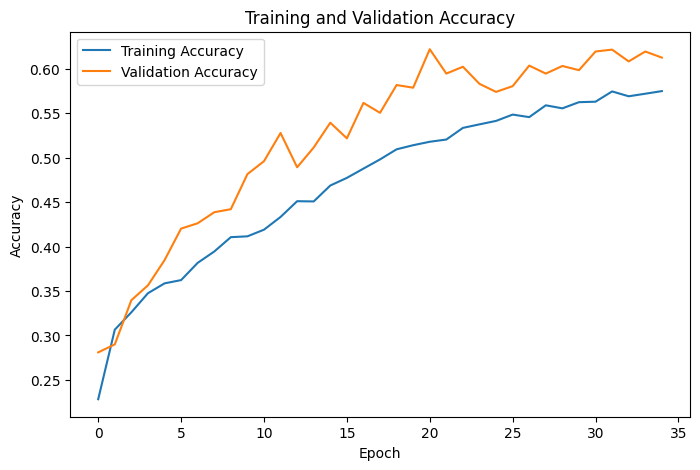

In [19]:
plt.figure(figsize=(8, 5))
plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training and Validation Accuracy")
plt.legend()
plt.show()

# Evaluate on Test Set

In [20]:
test_loss, test_accuracy = model.evaluate(test_ds)

print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")

72/72 ━━━━━━━━━━━━━━━━━━━━ 3s 38ms/step - accuracy: 0.6168 - loss: 0.9278
Test Loss: 0.9278
Test Accuracy: 0.6168


**Classification Report and Confusion Matrix**

In [21]:
y_true = []
y_pred = []

for images, labels in test_ds:
    predictions = model.predict(images, verbose=0)
    predicted_classes = np.argmax(predictions, axis=1)

    y_true.extend(labels.numpy())
    y_pred.extend(predicted_classes)

y_true = np.array(y_true)
y_pred = np.array(y_pred)

In [22]:
print(classification_report(
    y_true,
    y_pred,
    target_names=class_names
))

              precision    recall  f1-score   support

      Ahegao       0.91      0.88      0.89       172
       Angry       0.30      0.77      0.43       190
       Happy       0.86      0.72      0.78       502
     Neutral       0.61      0.58      0.60       612
         Sad       0.67      0.44      0.53       623
    Surprise       0.56      0.66      0.61       205

    accuracy                           0.62      2304
   macro avg       0.65      0.67      0.64      2304
weighted avg       0.67      0.62      0.63      2304



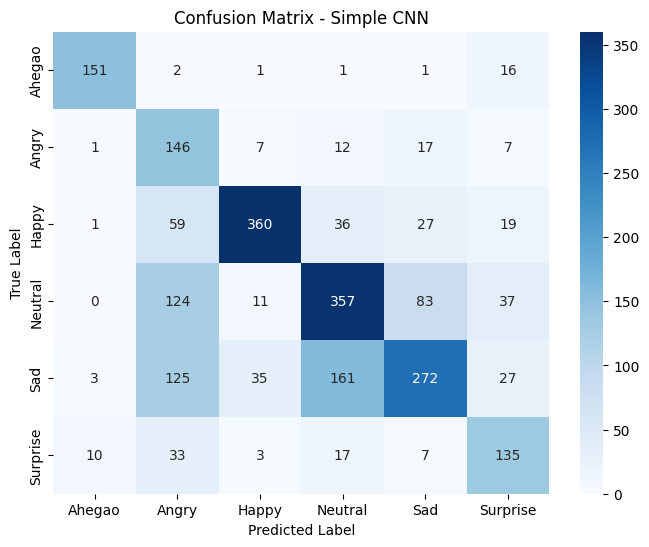

In [23]:
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=class_names,
    yticklabels=class_names,
    cmap="Blues"
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix - Simple CNN")
plt.show()

# Showing Sample Predictions

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step


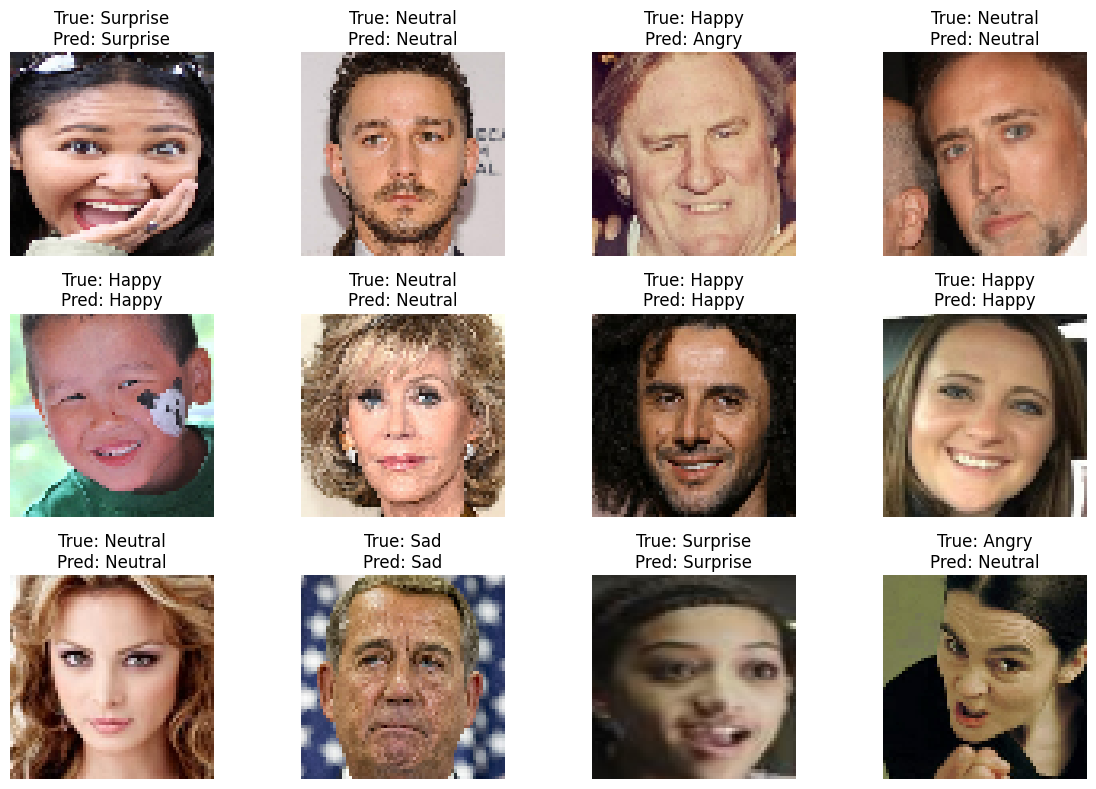

In [24]:
plt.figure(figsize=(12, 8))

for images, labels in test_ds.take(1):
    predictions = model.predict(images)
    predicted_classes = np.argmax(predictions, axis=1)

    for i in range(min(12, len(images))):
        plt.subplot(3, 4, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))

        true_label = class_names[labels[i]]
        predicted_label = class_names[predicted_classes[i]]

        plt.title(f"True: {true_label}\nPred: {predicted_label}")
        plt.axis("off")

plt.tight_layout()
plt.show()

In [25]:
model.save("/content/drive/MyDrive/simple_cnn_emotion_model.keras")